In [1]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset from your current working directory
df = pd.read_csv('Unemployment in India.csv')

## Data Preprocessing

In [3]:
# Clean column names (remove leading/trailing extra spaces)
df.columns = df.columns.str.strip()

In [4]:
#viewing baic data information and shape
df.head()
df.describe()
df.info ()
df.dtypes
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


(768, 7)

## Data Cleaning

In [5]:
# Check for missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [6]:
# Drop the 28 blank/null rows and check duplicates
df = df.dropna().reset_index(drop=True)
print("Duplicate rows count:", df.duplicated().sum())

Duplicate rows count: 0


In [7]:
# Verify zero null values remain
print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [8]:
# Convert 'Date' to datetime and extract Month and Year
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

# Display clean preview
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019


## Exploartory Data Analysis

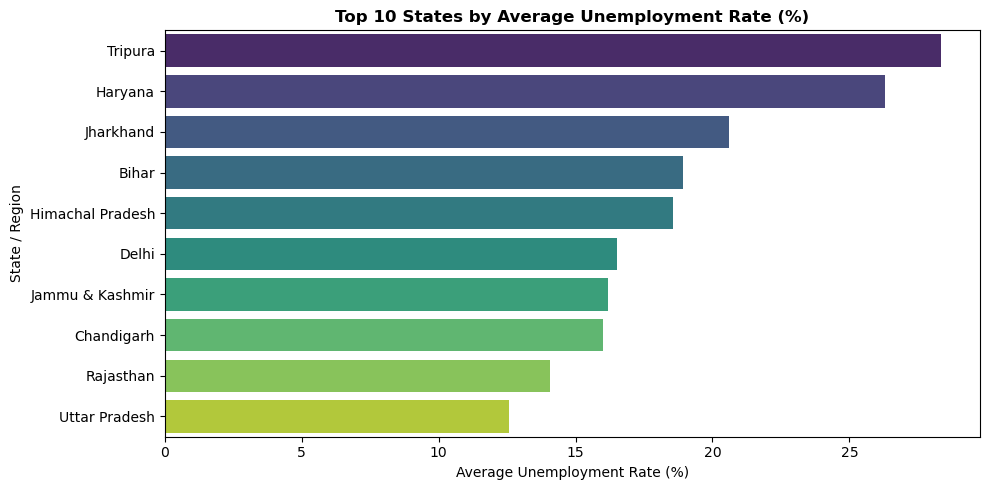

In [9]:
# Bar Chart: Average Unemployment Rate by Region (Top 10 States)
plt.figure(figsize=(10, 5))
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=region_avg, x='Estimated Unemployment Rate (%)', y='Region', hue='Region', palette='viridis', legend=False)
plt.title('Top 10 States by Average Unemployment Rate (%)', fontsize=12, fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / Region')
plt.tight_layout()
plt.show()

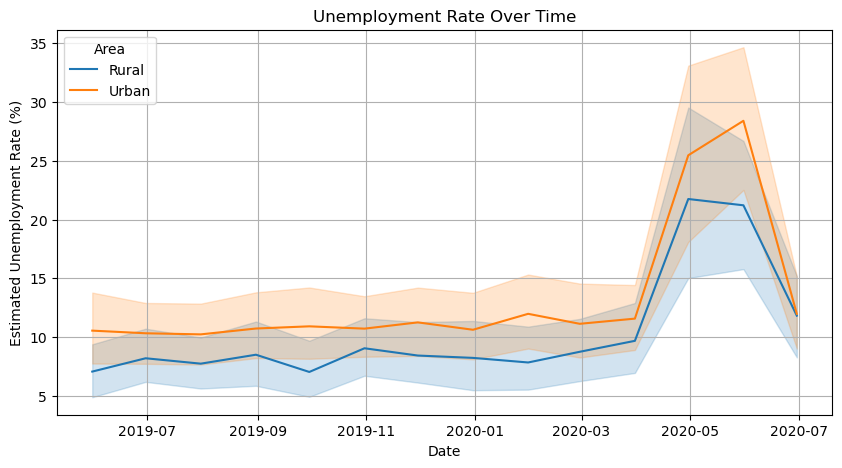

In [10]:
# Line plot for Unemployment Rate over time by Area
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area')
plt.title('Unemployment Rate Over Time')
plt.grid(True)
plt.show()

## Graph Interpretation
### Pre-2020 Stability: Unemployment held steady from mid-2019 to early 2020, floating around 5–10% in rural areas and 10–12% in urban centers.

### COVID Lockdown Spike: Rates skyrocketed in April–May 2020, peaking near 30% in urban areas and over 20% in rural regions.

### Urban vs. Rural: Urban areas suffered worse hit rates and higher volatility throughout the spike.

### Sharp Recovery: By July 2020, both sectors dropped back close to baseline pre-pandemic levels.

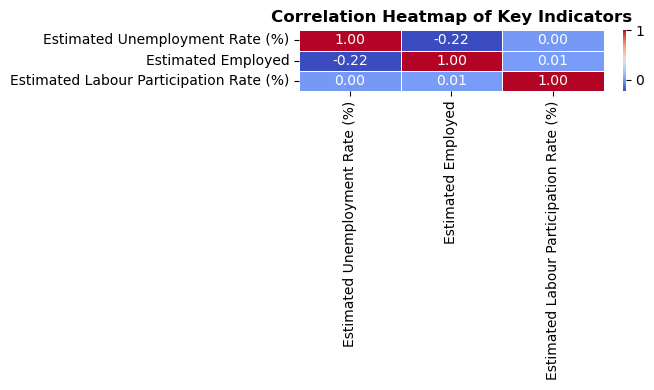

In [11]:
#  Heatmap: Feature Correlation Matrix
plt.figure(figsize=(7, 4))
numeric_cols = df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Key Indicators', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary & Insights

1. State-Level Disparities (Bar Chart):
   - Tripura registered the highest average unemployment rate in the dataset at nearly 28%, closely followed by Haryana (~26%) and Jharkhand(~21%).
   - Uttar Pradesh (~12.5%) and Rajasthan (~14%) maintained lower average unemployment rates relative to the top 10 states.

2. Impact of Lockdown & Temporal Spikes (Line Chart):
   - Baseline (May 2019 – March 2020): Unemployment remained stable, hovering between 5% and 10% for rural areas and 10% and 12% for urban regions.
   - Lockdown Peak (April – May 2020): Both regions experienced a massive surge due to COVID-19 restriction measures. Urban unemployment peaked at approximately 28%, while rural unemployment spiked to around 22%.
   - Recovery Phase (June – July 2020): Both sectors saw a rapid drop back toward pre-lockdown levels as economic activities resumed.

3. Key Indicator Relationships (Heatmap Correlation):
   - Unemployment Rate vs. Estimated Employed (-0.22): Weak-to-moderate negative correlation, confirming that as total employment figures shrink, unemployment rates rise.
   - Unemployment Rate vs. Labour Participation Rate (0.00): No direct linear correlation, indicating that workforce participation remained constant regardless of short-term unemployment fluctuations.